# SigFormer quickstart, cleaned up

This version is organized as:

1. `libraries`
2. `functions`
3. `config`
4. `demo`

Changes included:

- residual-related outputs are routed to `_`
- simulated data now uses sufficient-depth samples
- each active signature is guaranteed at least 100 mutations
- SigFormer and MuSiCal are compared side by side
- the first 3 simulated samples get composition plots and trinucleotide-context plots


## libraries


In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity

from YZ_vis_sig import get_COSMIC
from s01_SigFormer_Core import SigFormerCore


## functions


In [2]:
VEC_SUBSTIT = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
VEC_CONTEXT = [f"{x}-{y}" for x in "ACGT" for y in "ACGT"]
VEC_SUB_CTX = [f"{sub},{ctx}" for sub in VEC_SUBSTIT for ctx in VEC_CONTEXT]
XTIC_3NT = [f"{ctx[4]}{ctx[0]}{ctx[6]}" for ctx in VEC_SUB_CTX]
COLORS_96 = (
    ["#1e90ff"] * 16 +
    ["#000000"] * 16 +
    ["#ff0000"] * 16 +
    ["#b3b3b3"] * 16 +
    ["#9acd32"] * 16 +
    ["#eeaeee"] * 16
)


def set_seed(seed: int = 2026) -> np.random.Generator:
    """Set random seeds / 设置随机种子。"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return np.random.default_rng(seed)


def row_normalize(df: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    """Normalize each row to sum to 1 / 按行归一化到和为 1。"""
    denom = df.sum(axis=1).replace(0, np.nan)
    out = df.div(denom, axis=0).fillna(0.0)
    return out.clip(lower=0.0)


def _latest_checkpoint(ckpt_dir: Path) -> Path:
    """Pick the latest checkpoint / 自动选择最新 checkpoint。"""
    pt_files = sorted(ckpt_dir.glob("*.pt"))
    if not pt_files:
        raise FileNotFoundError(f"No checkpoint found in {ckpt_dir}")
    return pt_files[-1]


class SigFormerV6Wrapper:
    """
    Thin inference wrapper / 精简推理封装

    Notes
    -----
    Residual-related outputs are intentionally routed to `_`.
    这里故意不暴露 residual 相关输出，避免 demo 被这些信息干扰。
    """

    def __init__(
        self,
        model_dir: Union[str, Path],
        device: Union[str, torch.device] = "cpu",
        checkpoint: Optional[Union[str, Path]] = None,
        simplex: str = "sparsemax",
        mask_min_composition: float = 1e-3,
        mask_confidence_threshold: float = 0.35,
        mask_mode: str = "soft",
        mask_soft_power: float = 2.0,
    ) -> None:
        self.model_dir = Path(model_dir)
        self.device = torch.device(device)
        self.simplex = simplex
        self.mask_min_composition = mask_min_composition
        self.mask_confidence_threshold = mask_confidence_threshold
        self.mask_mode = mask_mode
        self.mask_soft_power = mask_soft_power

        ckpt_dir = self.model_dir / "3_model_wts"
        if not ckpt_dir.exists():
            raise FileNotFoundError(f"Cannot find weight folder: {ckpt_dir}")

        if checkpoint is None:
            ckpt_path = _latest_checkpoint(ckpt_dir)
        else:
            ckpt_path = Path(checkpoint)
            if not ckpt_path.is_file():
                ckpt_path = ckpt_dir / str(checkpoint)
            if not ckpt_path.is_file():
                raise FileNotFoundError(f"Checkpoint not found: {checkpoint}")

        print(f"[SigFormer] loading checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location="cpu")
        args = ckpt.get("args", {})

        self.model = SigFormerCore(
            n_chann=96,
            d_model=args["model_d_model"],
            n_heads=args["model_n_heads"],
            n_L_smp=args["model_smp_n_lyr"],
            n_L_ref=args["model_ref_n_lyr"],
            dropout=args["model_dropout"],
            confidence_detach_backbone=True,
        )

        state_dict = ckpt.get("model_state_dict", ckpt.get("state_dict"))
        if state_dict is None:
            raise KeyError("Cannot find model state dict in checkpoint.")
        self.model.load_state_dict(state_dict, strict=False)
        self.model.to(self.device)
        self.model.eval()

    def predict(
        self,
        df_counts: pd.DataFrame,
        df_refsig: pd.DataFrame,
        simplex: Optional[str] = None,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        Run SigFormer inference / 运行 SigFormer 推理。

        Parameters
        ----------
        df_counts : samples x 96
        df_refsig : signatures x 96

        Returns
        -------
        df_comp : raw predicted composition / 原始composition预测
        df_conf : confidence / 置信度
        df_mask : confidence-aware masked composition / mask后composition
        df_recon_counts : reconstructed counts / 重建counts
        """
        simplex_mode = self.simplex if simplex is None else simplex
        depth = df_counts.sum(axis=1).astype(float)

        with torch.no_grad():
            x = torch.tensor(df_counts.values.astype(np.float32), device=self.device)
            ref = torch.tensor(df_refsig.values.astype(np.float32), device=self.device)
            ref = ref.unsqueeze(0).expand(x.size(0), -1, -1).contiguous()

            comp_pred, conf_pred, _ = self.model(x, ref, simplex=simplex_mode, return_aux=True)
            comp_mask = self.model.build_masked_composition(
                comp_pred,
                conf_pred,
                min_composition=self.mask_min_composition,
                confidence_threshold=self.mask_confidence_threshold,
                mode=self.mask_mode,
                soft_power=self.mask_soft_power,
            )

        df_comp = pd.DataFrame(comp_pred.cpu().numpy(), index=df_counts.index, columns=df_refsig.index)
        df_conf = pd.DataFrame(conf_pred.cpu().numpy(), index=df_counts.index, columns=df_refsig.index)
        df_mask = pd.DataFrame(comp_mask.cpu().numpy(), index=df_counts.index, columns=df_refsig.index)

        df_profile = row_normalize(df_comp).values @ row_normalize(df_refsig).values
        df_recon_counts = pd.DataFrame(
            df_profile * depth.to_numpy()[:, None],
            index=df_counts.index,
            columns=df_counts.columns,
        )
        return df_comp, df_conf, df_mask, df_recon_counts


def run_musical_refit(
    df_counts: pd.DataFrame,
    df_refsig: pd.DataFrame,
    method: str = "likelihood_bidirectional",
    thresh: float = 1e-3,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run MuSiCal refitting / 运行 MuSiCal refit。

    MuSiCal expects:
    X = mutation_type x sample
    W = mutation_type x signature
    """
    try:
        import musical
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "MuSiCal is not installed. Install the parklab/MuSiCal package first."
        ) from exc

    X = df_counts.T.copy()
    W = row_normalize(df_refsig).T.copy()

    H, _ = musical.refit.refit(X, W, method=method, thresh=thresh)

    if isinstance(H, pd.DataFrame):
        df_exp = H.copy()
    else:
        df_exp = pd.DataFrame(H, index=W.columns, columns=X.columns)

    df_exp = df_exp.reindex(index=df_refsig.index, columns=df_counts.index).fillna(0.0)
    df_comp = row_normalize(df_exp.T)
    df_recon_counts = pd.DataFrame(
        (W.values @ df_exp.values).T,
        index=df_counts.index,
        columns=df_counts.columns,
    )
    return df_comp, df_recon_counts


def choose_signature_subset(df_cosmic: pd.DataFrame, signature_names: Sequence[str]) -> pd.DataFrame:
    """Pick a readable subset / 选择更适合 demo 展示的 signature 子集。"""
    missing = [x for x in signature_names if x not in df_cosmic.index]
    if missing:
        warnings.warn(f"Missing signatures ignored: {missing}")
    keep = [x for x in signature_names if x in df_cosmic.index]
    if not keep:
        raise ValueError("No requested signatures found in COSMIC table.")
    return row_normalize(df_cosmic.loc[keep, VEC_SUB_CTX].copy())


def sample_exposure_counts(
    n_sig: int,
    depth: int,
    rng: np.random.Generator,
    n_active_range: Tuple[int, int],
    min_per_signature: int,
) -> np.ndarray:
    """
    Sample exposure counts with a hard floor / 采样 exposure，并保证每个活跃 signature 至少有固定突变数。
    """
    min_k, max_k = n_active_range
    k_max_allowed = min(max_k, n_sig, depth // min_per_signature)
    if k_max_allowed < min_k:
        raise ValueError(
            f"Depth={depth} is too small for min_per_signature={min_per_signature} "
            f"and n_active_range={n_active_range}."
        )

    k = int(rng.integers(min_k, k_max_allowed + 1))
    active = rng.choice(n_sig, size=k, replace=False)

    base = np.zeros(n_sig, dtype=int)
    base[active] = min_per_signature

    remaining = int(depth - base.sum())
    if remaining > 0:
        extra_w = rng.dirichlet(np.ones(k))
        extra = rng.multinomial(remaining, extra_w)
        base[active] += extra
    return base


def simulate_dataset(
    df_refsig: pd.DataFrame,
    sample_prefix: str,
    n_samples: int,
    depth_choices: Sequence[int],
    noise_concentration: float,
    rng: np.random.Generator,
    n_active_range: Tuple[int, int] = (2, 5),
    min_per_signature: int = 100,
) -> Dict[str, pd.DataFrame]:
    """
    Simulate sufficient-depth catalogs / 构建高深度模拟数据。

    noise_concentration:
        Dirichlet concentration around the expected 96D profile.
        值越大，围绕期望 profile 的波动越小。
    """
    ref = row_normalize(df_refsig)
    n_sig = ref.shape[0]

    counts_rows = []
    truth_rows = []
    expected_rows = []
    meta_rows = []

    for i in range(n_samples):
        sample_id = f"{sample_prefix}_{i+1:02d}"
        depth = int(rng.choice(depth_choices))
        exposure_counts = sample_exposure_counts(
            n_sig=n_sig,
            depth=depth,
            rng=rng,
            n_active_range=n_active_range,
            min_per_signature=min_per_signature,
        )

        composition = exposure_counts / exposure_counts.sum()
        expected_profile = composition @ ref.values

        alpha = np.clip(expected_profile, 1e-10, None) * float(noise_concentration)
        noisy_profile = rng.dirichlet(alpha)
        observed_counts = rng.multinomial(depth, noisy_profile)

        counts_rows.append(pd.Series(observed_counts, index=ref.columns, name=sample_id))
        truth_rows.append(pd.Series(composition, index=ref.index, name=sample_id))
        expected_rows.append(pd.Series(expected_profile * depth, index=ref.columns, name=sample_id))
        meta_rows.append(
            {
                "sample": sample_id,
                "depth": depth,
                "noise_concentration": noise_concentration,
                "n_active": int((exposure_counts > 0).sum()),
                "min_active_count": int(exposure_counts[exposure_counts > 0].min()),
            }
        )

    return {
        "df_counts": pd.DataFrame(counts_rows),
        "df_truth": pd.DataFrame(truth_rows),
        "df_expected_counts": pd.DataFrame(expected_rows),
        "df_meta": pd.DataFrame(meta_rows).set_index("sample"),
    }


def combine_simulations(sim_list: Sequence[Dict[str, pd.DataFrame]]) -> Dict[str, pd.DataFrame]:
    """Concatenate multiple simulated batches / 合并多个模拟批次。"""
    keys = sim_list[0].keys()
    out = {}
    for key in keys:
        out[key] = pd.concat([x[key] for x in sim_list], axis=0)
    return out


def reconstruct_counts_from_composition(
    df_comp: pd.DataFrame,
    df_refsig: pd.DataFrame,
    depths: pd.Series,
) -> pd.DataFrame:
    """Composition -> reconstructed counts / composition 转为重建 counts。"""
    profile = row_normalize(df_comp).values @ row_normalize(df_refsig).values
    recon = profile * depths.reindex(df_comp.index).to_numpy()[:, None]
    return pd.DataFrame(recon, index=df_comp.index, columns=df_refsig.columns)


def rowwise_cosine(df_a: pd.DataFrame, df_b: pd.DataFrame) -> pd.Series:
    """Row-wise cosine similarity / 按行计算 cosine similarity。"""
    a = df_a.to_numpy(dtype=float)
    b = df_b.reindex_like(df_a).to_numpy(dtype=float)
    sims = []
    for i in range(a.shape[0]):
        sims.append(float(cosine_similarity(a[i:i+1], b[i:i+1])[0, 0]))
    return pd.Series(sims, index=df_a.index)


def evaluate_prediction(
    df_truth: pd.DataFrame,
    df_pred: pd.DataFrame,
    df_counts: pd.DataFrame,
    df_recon_counts: pd.DataFrame,
    method_name: str,
    support_threshold: float = 0.01,
) -> pd.DataFrame:
    """
    Compute a compact performance table / 生成紧凑的性能评估表。
    """
    truth = row_normalize(df_truth)
    pred = row_normalize(df_pred).reindex_like(truth).fillna(0.0)
    recon = df_recon_counts.reindex_like(df_counts).fillna(0.0)

    mae = (truth - pred).abs().mean(axis=1)
    l1 = (truth - pred).abs().sum(axis=1)
    cos_comp = rowwise_cosine(truth, pred)

    truth_mask = (truth >= support_threshold).astype(int)
    pred_mask = (pred >= support_threshold).astype(int)

    prf = [
        precision_recall_fscore_support(
            truth_mask.loc[sample],
            pred_mask.loc[sample],
            average="binary",
            zero_division=0,
        )
        for sample in truth.index
    ]
    precision = pd.Series([x[0] for x in prf], index=truth.index)
    recall = pd.Series([x[1] for x in prf], index=truth.index)
    f1 = pd.Series([x[2] for x in prf], index=truth.index)

    obs_freq = row_normalize(df_counts)
    recon_freq = row_normalize(recon)
    cos_recon = rowwise_cosine(obs_freq, recon_freq)

    out = pd.DataFrame(
        {
            "method": method_name,
            "composition_mae": mae,
            "composition_l1": l1,
            "composition_cosine": cos_comp,
            "support_precision": precision,
            "support_recall": recall,
            "support_f1": f1,
            "reconstruction_cosine": cos_recon,
        },
        index=truth.index,
    )
    return out


def build_scatter_df(
    df_truth: pd.DataFrame,
    pred_dict: Dict[str, pd.DataFrame],
    min_show: float = 1e-4,
) -> pd.DataFrame:
    """Convert truth/prediction to long form / 整理成 scatter 用长表。"""
    rows = []
    truth = row_normalize(df_truth)
    for method, df_pred in pred_dict.items():
        pred = row_normalize(df_pred).reindex_like(truth).fillna(0.0)
        for sample in truth.index:
            for sig in truth.columns:
                t = float(truth.loc[sample, sig])
                p = float(pred.loc[sample, sig])
                if (t >= min_show) or (p >= min_show):
                    rows.append(
                        {
                            "sample": sample,
                            "signature": sig,
                            "method": method,
                            "truth": t,
                            "prediction": p,
                            "active_truth": int(t > 0),
                        }
                    )
    return pd.DataFrame(rows)


def plot_prediction_scatter(df_scatter: pd.DataFrame, output: Optional[Path] = None) -> plt.Figure:
    """Prediction vs truth scatter / 真值与预测散点图。"""
    methods = df_scatter["method"].unique().tolist()
    fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5), squeeze=False)

    lim = max(df_scatter["truth"].max(), df_scatter["prediction"].max()) * 1.02
    lim = max(lim, 0.05)

    for ax, method in zip(axes[0], methods):
        sub = df_scatter[df_scatter["method"] == method].copy()
        ax.scatter(
            sub["truth"] * 100,
            sub["prediction"] * 100,
            s=18,
            alpha=0.6,
            linewidth=0,
        )
        ax.plot([0, lim * 100], [0, lim * 100], linestyle="--", linewidth=1.2)
        ax.set_title(f"{method}: prediction vs truth")
        ax.set_xlabel("Truth (%)")
        ax.set_ylabel("Prediction (%)")
        ax.set_xlim(0, lim * 100)
        ax.set_ylim(0, lim * 100)

    fig.tight_layout()
    if output is not None:
        fig.savefig(output, dpi=200, bbox_inches="tight")
    return fig


def plot_metric_boxplots(df_eval: pd.DataFrame, output: Optional[Path] = None) -> plt.Figure:
    """Boxplots for sample-level metrics / 样本级指标 boxplot。"""
    metrics = [
        "composition_mae",
        "composition_cosine",
        "support_f1",
        "reconstruction_cosine",
    ]
    methods = df_eval["method"].unique().tolist()

    fig, axes = plt.subplots(1, len(metrics), figsize=(4.8 * len(metrics), 4.8), squeeze=False)

    for ax, metric in zip(axes[0], metrics):
        data = [df_eval.loc[df_eval["method"] == m, metric].values for m in methods]
        ax.boxplot(data, tick_labels=methods, patch_artist=False)
        ax.set_title(metric)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    fig.tight_layout()
    if output is not None:
        fig.savefig(output, dpi=200, bbox_inches="tight")
    return fig


def summarize_performance(df_eval: pd.DataFrame, df_meta: pd.DataFrame) -> pd.DataFrame:
    """Aggregate metrics by method and noise / 按 method 和 noise 汇总指标。"""
    df = df_eval.join(df_meta[["noise_concentration", "depth"]], how="left")
    grp = (
        df.groupby(["method", "noise_concentration"])[
            ["composition_mae", "composition_cosine", "support_f1", "reconstruction_cosine", "depth"]
        ]
        .agg(["mean", "median"])
    )
    return grp.round(4)


def _collapse_other(s: pd.Series, keep_names: Sequence[str]) -> pd.Series:
    """Keep selected signatures, collapse the rest into 'Other' / 其余合并到 Other。"""
    keep_names = [x for x in keep_names if x in s.index]
    out = s.reindex(keep_names, fill_value=0.0).copy()
    other = float(s.sum() - out.sum())
    if other > 0:
        out["Other"] = other
    return out


def plot_sample_composition_bars(
    sample_id: str,
    truth: pd.Series,
    sigformer: pd.Series,
    musical: pd.Series,
    output: Optional[Path] = None,
) -> plt.Figure:
    """
    Plot horizontal stacked bars for one sample / 单个样本的 composition 堆叠条形图。
    """
    truth = row_normalize(truth.to_frame().T).iloc[0]
    sigformer = row_normalize(sigformer.to_frame().T).iloc[0]
    musical = row_normalize(musical.to_frame().T).iloc[0]

    top_union = (
        pd.concat([truth, sigformer, musical], axis=1)
        .max(axis=1)
        .sort_values(ascending=False)
        .head(8)
        .index
        .tolist()
    )

    plot_df = pd.DataFrame(
        {
            "Truth": _collapse_other(truth, top_union),
            "SigFormer": _collapse_other(sigformer, top_union),
            "MuSiCal": _collapse_other(musical, top_union),
        }
    ).T.fillna(0.0)

    colors = plt.cm.tab20(np.linspace(0, 1, plot_df.shape[1]))
    fig, ax = plt.subplots(figsize=(10, 2.8))
    left = np.zeros(plot_df.shape[0])

    for j, col in enumerate(plot_df.columns):
        vals = plot_df[col].values * 100
        ax.barh(plot_df.index, vals, left=left, label=col, color=colors[j], edgecolor="white", linewidth=0.5)
        left += vals

    ax.set_title(f"{sample_id}: signature composition")
    ax.set_xlabel("Composition (%)")
    ax.legend(ncol=min(5, plot_df.shape[1]), bbox_to_anchor=(1.01, 1.0), loc="upper left")
    fig.tight_layout()

    if output is not None:
        fig.savefig(output, dpi=200, bbox_inches="tight")
    return fig


def plot_96_context_overlay(
    sample_id: str,
    observed_counts: pd.Series,
    expected_counts: pd.Series,
    sigformer_counts: pd.Series,
    musical_counts: pd.Series,
    output: Optional[Path] = None,
) -> plt.Figure:
    """
    Plot trinucleotide context for one sample / 绘制单个样本的 96D context 图。
    """
    obs = row_normalize(observed_counts.to_frame().T).iloc[0]
    exp = row_normalize(expected_counts.to_frame().T).iloc[0]
    sfg = row_normalize(sigformer_counts.to_frame().T).iloc[0]
    mus = row_normalize(musical_counts.to_frame().T).iloc[0]

    fig, ax = plt.subplots(figsize=(16, 4.5))
    x = np.arange(96)

    ax.bar(x, obs.values * 100, color=COLORS_96, edgecolor="none", alpha=0.65, label="Observed")
    ax.plot(x, exp.values * 100, linewidth=1.5, label="Truth expectation")
    ax.plot(x, sfg.values * 100, linewidth=1.5, label="SigFormer")
    ax.plot(x, mus.values * 100, linewidth=1.5, label="MuSiCal")

    ymax = max(
        (obs.values * 100).max(),
        (exp.values * 100).max(),
        (sfg.values * 100).max(),
        (mus.values * 100).max(),
    )

    rec_y = ymax * 1.08
    rec_h = ymax * 0.08
    txt_y = ymax * 1.18
    blocks = [
        (0, "#1e90ff", "C>A"),
        (16, "#000000", "C>G"),
        (32, "#ff0000", "C>T"),
        (48, "#b3b3b3", "T>A"),
        (64, "#9acd32", "T>C"),
        (80, "#eeaeee", "T>G"),
    ]
    for start, color, label in blocks:
        ax.add_patch(
            patches.Rectangle((start - 0.5, rec_y), 16, rec_h, facecolor=color, edgecolor="none", clip_on=False)
        )
        ax.text(start + 8, txt_y, label, ha="center", va="center", fontsize=10)

    ax.set_xlim(-1, 96)
    ax.set_ylim(0, ymax * 1.32)
    ax.set_xticks(x)
    ax.set_xticklabels(XTIC_3NT, rotation=90, fontsize=6)
    ax.set_ylabel("Frequency (%)")
    ax.set_title(f"{sample_id}: trinucleotide context")
    ax.legend(loc="upper right")
    fig.tight_layout()

    if output is not None:
        fig.savefig(output, dpi=200, bbox_inches="tight")
    return fig


## config


In [3]:
@dataclass
class DemoConfig:
    model_dir: Path = Path("trained_models/SigFormer_V6_main")
    checkpoint: Optional[str] = None
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    simplex: str = "sparsemax"

    output_dir: Path = Path("demo_sigformer_vs_musical")

    seed: int = 2026
    depth_choices: Tuple[int, ...] = (3000, 5000, 8000, 12000)
    noise_levels: Tuple[float, ...] = (120.0, 230.0)
    n_samples_per_noise: int = 12
    n_active_range: Tuple[int, int] = (2, 5)
    min_per_signature: int = 100

    signature_names: Tuple[str, ...] = (
        "SBS1", "SBS2", "SBS4", "SBS5",
        "SBS7a", "SBS7b", "SBS13", "SBS17a",
        "SBS18", "SBS22", "SBS35", "SBS40",
    )

    musical_method: str = "likelihood_bidirectional"
    musical_thresh: float = 1e-3
    support_threshold: float = 0.01


CFG = DemoConfig()


## demo


/tmp/ipykernel_22414/197190363.py:198: UserWarning: Missing signatures ignored: ['SBS22', 'SBS40']
  warnings.warn(f"Missing signatures ignored: {missing}")


[INFO] reference signatures: 10
[INFO] output directory: /storage/zong/home/u244338/04_Mutation/m05_Sigformer/m19_SigFormer/demo_sigformer_vs_musical

[INFO] simulated dataset
counts shape : (24, 96)
truth shape  : (24, 10)
                           depth               n_active          \
                            mean   min    max      mean min max   
noise_concentration                                               
120.0                7750.000000  3000  12000  3.333333   2   5   
230.0                6416.666667  3000  12000  3.500000   2   5   

                    min_active_count             
                                mean  min   max  
noise_concentration                              
120.0                    1433.833333  147  4919  
230.0                     812.583333  129  2492  
[SigFormer] loading checkpoint: runs/SigFormer_V6_main/3_model_wts/SigFormer_v6_epoch300.pt

[INFO] performance summary
                              composition_mae         composition_cosi

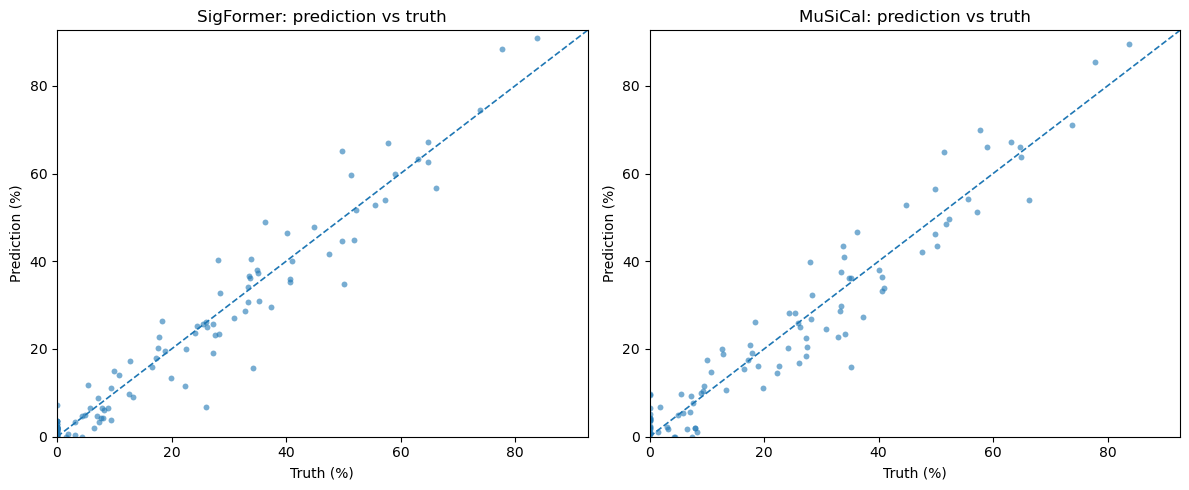

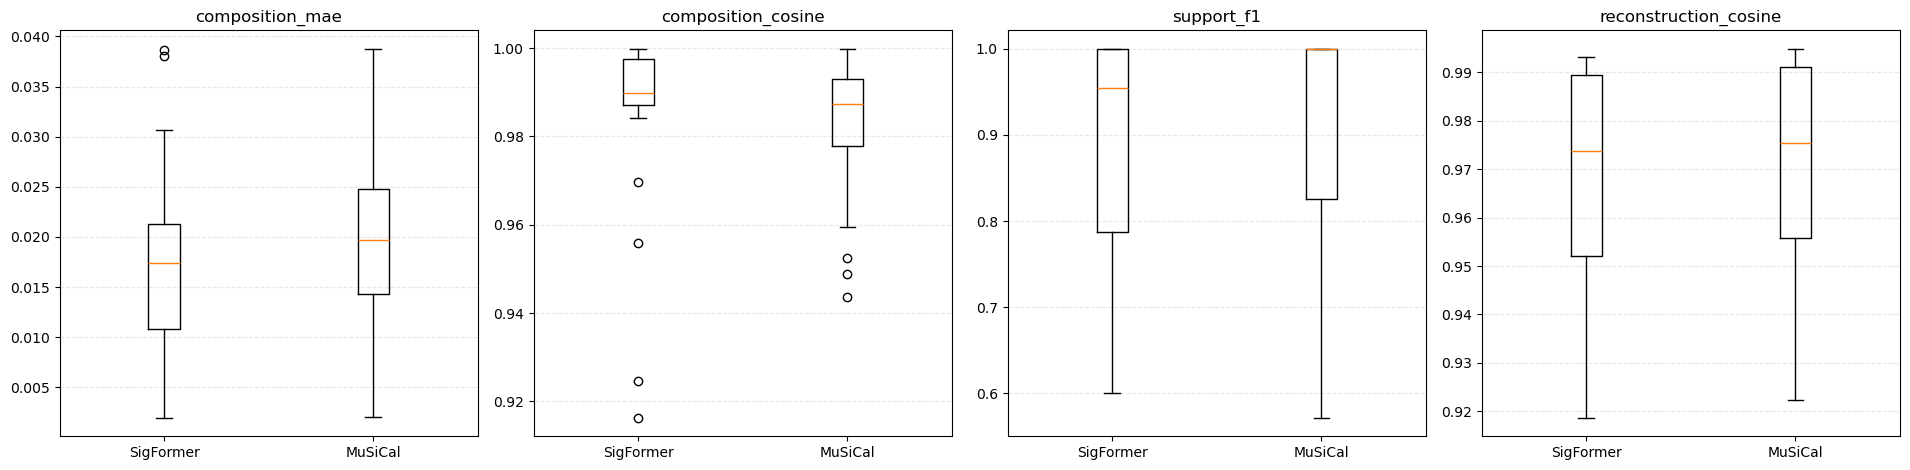


[INFO] showcase samples: ['noise120_01', 'noise120_02', 'noise120_03']


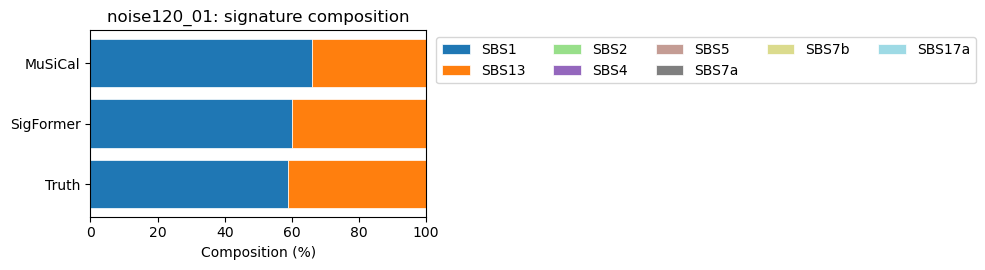

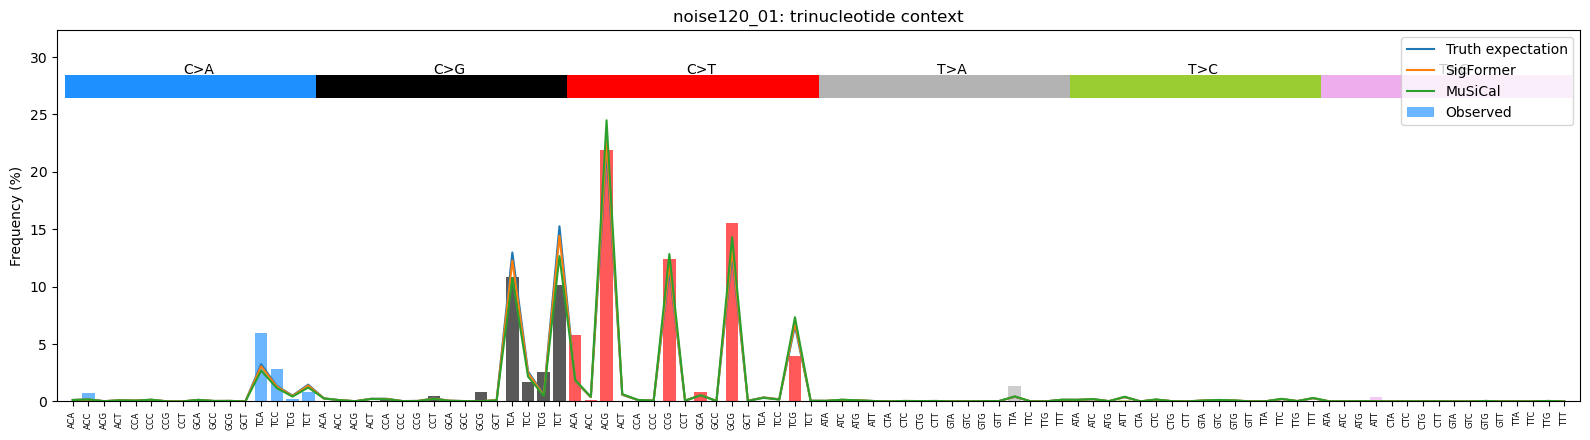

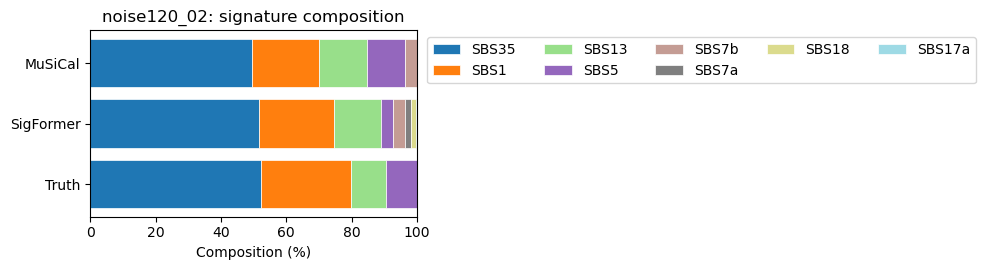

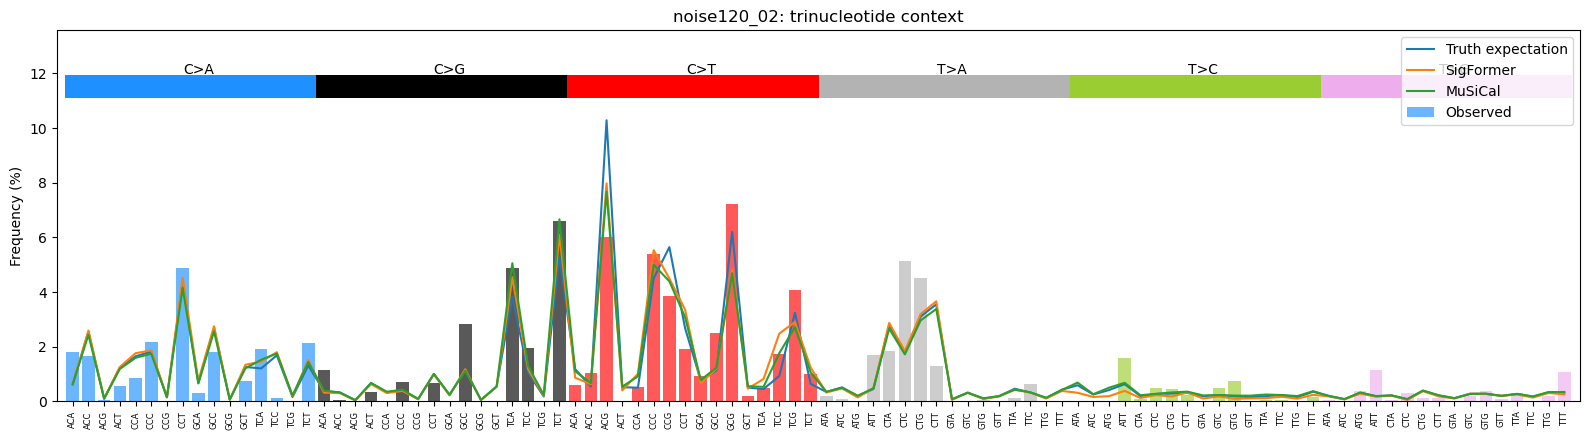

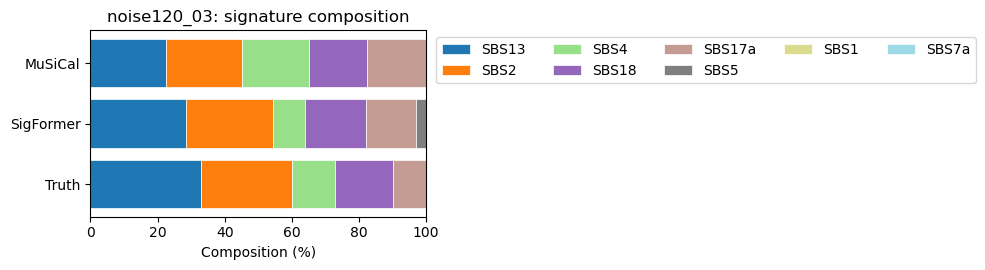

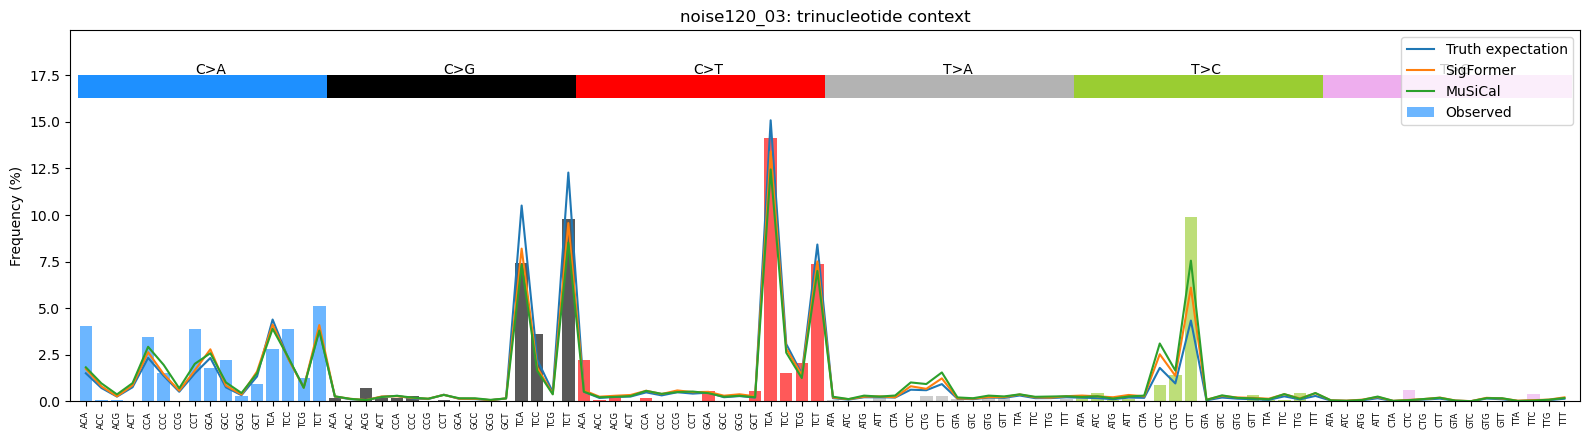


[DONE] all demo outputs were written to:
/storage/zong/home/u244338/04_Mutation/m05_Sigformer/m19_SigFormer/demo_sigformer_vs_musical


In [4]:
rng = set_seed(CFG.seed)
CFG.output_dir.mkdir(parents=True, exist_ok=True)

# 1) load reference signatures / 读取参考 signature
df_cosmic = get_COSMIC()
df_refsig = choose_signature_subset(df_cosmic, CFG.signature_names)

print(f"[INFO] reference signatures: {df_refsig.shape[0]}")
print(f"[INFO] output directory: {CFG.output_dir.resolve()}")

# 2) simulate two noise cohorts / 构建两组不同 noise 的模拟数据
sim_batches = []
for noise in CFG.noise_levels:
    sim_batches.append(
        simulate_dataset(
            df_refsig=df_refsig,
            sample_prefix=f"noise{int(noise)}",
            n_samples=CFG.n_samples_per_noise,
            depth_choices=CFG.depth_choices,
            noise_concentration=noise,
            rng=rng,
            n_active_range=CFG.n_active_range,
            min_per_signature=CFG.min_per_signature,
        )
    )

demo = combine_simulations(sim_batches)
X_demo = demo["df_counts"]
Y_true = demo["df_truth"]
X_expected = demo["df_expected_counts"]
meta = demo["df_meta"]

print("\n[INFO] simulated dataset")
print("counts shape :", X_demo.shape)
print("truth shape  :", Y_true.shape)
print(meta.groupby("noise_concentration")[["depth", "n_active", "min_active_count"]].agg(["mean", "min", "max"]))

# 3) run SigFormer / 跑 SigFormer
sigformer = SigFormerV6Wrapper(
    model_dir=CFG.model_dir,
    device=CFG.device,
    checkpoint=CFG.checkpoint,
    simplex=CFG.simplex,
)
Y_sigformer_raw, Z_conf, Y_sigformer_mask, X_sigformer_recon = sigformer.predict(X_demo, df_refsig)

# choose masked result for comparison / 用 masked 结果做比较更接近实际使用场景
Y_sigformer = row_normalize(Y_sigformer_mask)

# 4) run MuSiCal / 跑 MuSiCal
Y_musical, X_musical_recon = run_musical_refit(
    df_counts=X_demo,
    df_refsig=df_refsig,
    method=CFG.musical_method,
    thresh=CFG.musical_thresh,
)

# 5) evaluate / 评估性能
df_eval_sigformer = evaluate_prediction(
    df_truth=Y_true,
    df_pred=Y_sigformer,
    df_counts=X_demo,
    df_recon_counts=X_sigformer_recon,
    method_name="SigFormer",
    support_threshold=CFG.support_threshold,
)
df_eval_musical = evaluate_prediction(
    df_truth=Y_true,
    df_pred=Y_musical,
    df_counts=X_demo,
    df_recon_counts=X_musical_recon,
    method_name="MuSiCal",
    support_threshold=CFG.support_threshold,
)

df_eval = pd.concat([df_eval_sigformer, df_eval_musical], axis=0)
df_eval.to_csv(CFG.output_dir / "performance_per_sample.tsv", sep="\t")

summary_tbl = summarize_performance(df_eval, meta)
summary_tbl.to_csv(CFG.output_dir / "performance_summary.tsv", sep="\t")

print("\n[INFO] performance summary")
print(summary_tbl)

# 6) scatter plot / 画 truth vs prediction 散点图
df_scatter = build_scatter_df(
    df_truth=Y_true,
    pred_dict={
        "SigFormer": Y_sigformer,
        "MuSiCal": Y_musical,
    },
)
df_scatter.to_csv(CFG.output_dir / "prediction_vs_truth_long.tsv", sep="\t", index=False)

fig = plot_prediction_scatter(df_scatter, output=CFG.output_dir / "prediction_vs_truth_scatter.png")
plt.show()

# 7) metric boxplots / 性能 boxplots
fig = plot_metric_boxplots(df_eval, output=CFG.output_dir / "performance_boxplots.png")
plt.show()

# 8) export composition tables / 导出 composition 表
Y_true.to_csv(CFG.output_dir / "truth_composition.tsv", sep="\t")
Y_sigformer.to_csv(CFG.output_dir / "sigformer_composition.tsv", sep="\t")
Y_musical.to_csv(CFG.output_dir / "musical_composition.tsv", sep="\t")
Z_conf.to_csv(CFG.output_dir / "sigformer_confidence.tsv", sep="\t")

# 9) detailed demo for the first three samples / 前三个样本的详细展示
showcase_samples = X_demo.index[:3].tolist()
print("\n[INFO] showcase samples:", showcase_samples)

for sample_id in showcase_samples:
    fig = plot_sample_composition_bars(
        sample_id=sample_id,
        truth=Y_true.loc[sample_id],
        sigformer=Y_sigformer.loc[sample_id],
        musical=Y_musical.loc[sample_id],
        output=CFG.output_dir / f"{sample_id}.composition.png",
    )
    plt.show()

    fig = plot_96_context_overlay(
        sample_id=sample_id,
        observed_counts=X_demo.loc[sample_id],
        expected_counts=X_expected.loc[sample_id],
        sigformer_counts=X_sigformer_recon.loc[sample_id],
        musical_counts=X_musical_recon.loc[sample_id],
        output=CFG.output_dir / f"{sample_id}.trinucleotide_context.png",
    )
    plt.show()

print("\n[DONE] all demo outputs were written to:")
print(CFG.output_dir.resolve())
